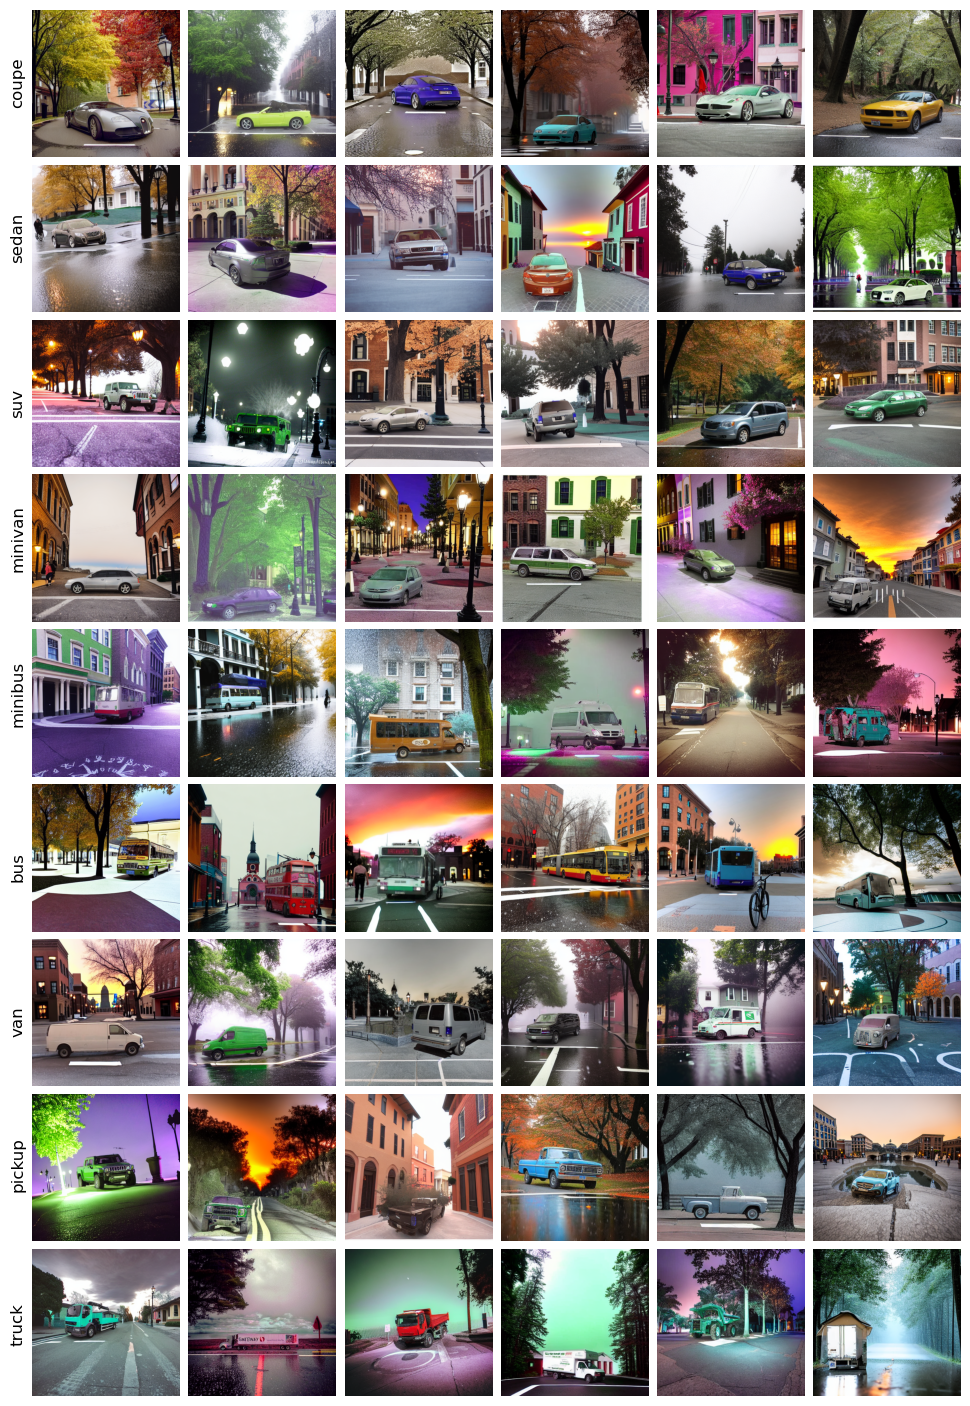

In [4]:
import os
import shutil
from src import detect, outpaint, utils
import matplotlib.pyplot as plt
import yaml
import re
from PIL import Image

# Load existing configuration
with open('config/aidovecl-config.yaml', 'r') as file:
    config = yaml.safe_load(file)

# Access the class_index dictionary
class_index = config['class_index']

base_path = "./figs/fig3"

def setup_directories():
    for key in ["seed", "seed_split", "outpainted"]:
        path = os.path.join(base_path, key)
        if os.path.exists(path):
            shutil.rmtree(path)
        os.makedirs(path)

def generate_seed_images():
    real_path = os.path.join(base_path, "real")
    seed_path = os.path.join(base_path, "seed")
    for vehicle_type in os.listdir(real_path):
        input_folder = os.path.join(real_path, vehicle_type)
        output_folder = os.path.join(seed_path, vehicle_type)
        print(vehicle_type)
        detect.process_folder(input_folder, output_folder)

def split_dataset():
    seed_path = os.path.join(base_path, "seed")
    seed_split_path = os.path.join(base_path, "seed_split")
    splitter = utils.DatasetSplitter(seed_path, seed_split_path, split_ratios={'train': 1, 'val': 0, 'test': 0})
    splitter.execute()

def perform_outpainting():
    seed_split_path = os.path.join(base_path, "seed_split")
    outpainted_path = os.path.join(base_path, "outpainted")
    outpaint.generate_outpainted(seed_split_path, outpainted_path, random_seed=0)


# plotting samples of classified images
class ImageLoader:
    def __init__(self, folder_path):
        self.folder_path = folder_path

    def load_images_from_folder(self):
        images = {}
        for filename in sorted(os.listdir(self.folder_path)):
            if filename.endswith((".png", ".jpg", ".jpeg")):
                class_name = re.split(r'\d', filename)[0].rstrip('_')
                class_name = class_name.replace('_', ' ')
                img_path = os.path.join(self.folder_path, filename)
                img = Image.open(img_path)
                if class_name in images:
                    images[class_name].append(img)
                else:
                    images[class_name] = [img]
        return images

    def plot_images(self, images, class_index):
        num_classes = len(class_index)
        max_images = max(len(img_list) for img_list in images.values())
        fig, axs = plt.subplots(num_classes, max_images, figsize=(max_images * 2, num_classes * 2))
        if num_classes == 1:
            axs = [axs]
        axs = [axs[j] if max_images > 1 else [axs[j]] for j in range(num_classes)]
        for class_name, row_index in class_index.items():
            if class_name in images:
                for col_index, img in enumerate(images[class_name]):
                    axs[row_index][col_index].imshow(img)
                    axs[row_index][col_index].axis('off')
                    if col_index == 0:
                        axs[row_index][col_index].set_title(class_name, loc='left', x=-0.15, y =.3, rotation=90)
        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        plt.savefig("./figs/fig3/outpainted.pdf", format="pdf", bbox_inches='tight', dpi=300)
        
def plot_outpainted_images():
    plt.rcdefaults()
    image_loader = ImageLoader(os.path.join(base_path, "outpainted", 'train', 'images'))
    images = image_loader.load_images_from_folder()
    image_loader.plot_images(images, class_index)


setup_directories()
generate_seed_images()
split_dataset()
perform_outpainting()
plot_outpainted_images()